# Contact Validation
## Theory: Linear Elasticity / Hyperelasticity with Dynamic Contact

Following references were used to implement the model:
- [Elastic Pendulum - NGS Tutorial 2024](https://docu.ngsolve.org/ngs24/tutorials/00_dynamics.html)
- [Contact Problems - NGS Docu Interactive Tutorial](https://docu.ngsolve.org/latest/i-tutorials/unit-6.2-contact/contact.html)
- [An Interactive Introduction to the Finite Element Method, Joachim Schöberl, TU Wien, ASC](https://jschoeberl.github.io/iFEM/intro.html)


### **1. Description**

This example describes a minimal impact problem in **2D** to validate the contact formulation.

A ball starting at a height of `h0_ball` is falling due to gravity and hits a wall.

The initial velocity of the ball is zero. The initial gap between the ball and the wall is `h_fall`.

The wall is fixed at the bottom edge in vertical direction and at the left and right edge in horizontal direction.

The wall is modeled as stiff steel plate using the linear elastic material law.

The ball is modeled as stiff and compliant body using the hyperelastic Neo-Hookean material law.

The contact is modeled using a **contact boundary** between the ball and the plate. It uses a coefficient function to track the distance between the two bodies.
The coefficient function is implemented in an **absolute** and **incremental** manner. If the coefficient function is evaluated positive, an energy term is added to the system equation. This energy term penalizes the penetration of the ball into the plate (see below).

The validation is based on the conservation of energy. The total energy is the sum of the kinetic energy, the potential energy due to gravity, the elastic strain energy, and the contact energy.

$$
\text{Total Energy} = \text{Kinetic Energy} + \text{Potential Energy} + \text{Contact Energy}
$$

Furthermore, the average velocity of the ball after the impact is compared to the theoretical value based on the initial potential energy.

$$
v_{\text{impact}} = \sqrt{2 \cdot g \cdot h_{\text{fall}}}
$$



### **2. Material Laws**

#### 2.1 Linear Elasticity

- Linear strain: $\epsilon = \frac{1}{2}(\nabla u + (\nabla u)^T)$
    - Displacement field: $u$

- Linear strain energy density: $\Psi = \mu \epsilon : \epsilon + \frac{\lambda}{2} (\text{trace}(\epsilon))^2$
    - Lamé parameters: $\mu, \lambda$

- Linear Stress: $\sigma = 2 \mu \epsilon + \lambda \operatorname{trace}(\epsilon) I$

#### 2.2 Hyperelasticity (Neo-Hookean)

- Deformation gradient $\mathbf F = \mathbf I + \operatorname{Grad}\vec u$, $F_{ij} = \delta_{ij} + \partial u_i/\partial X_j$

- Right Cauchy-Green tensor $\mathbf C = \mathbf F^T \cdot \mathbf F$

-  Green strain $\mathbf E = \frac{1}{2} (\mathbf C - \mathbf I)$

- Jacobi determinant $J = \operatorname{det}\mathbf F$

- Neo-Hookean strain energy density: $\Psi = \frac{\mu}{2} (\operatorname{trace} (\mathbf C - \mathbf I)) + \frac{2\mu}{\lambda} \operatorname{det}\mathbf (C)^{-\tfrac{\lambda}{2\mu}}-1$
    - Lamé parameters: $\mu, \lambda$

### **3. Contact Setup**

- Defines the contact boundary between the contact edges of the ball and the wall
    - Master: contact edge of the wall
    - Slave: contact edge of the ball

- `X_M`: Master surface reference coordinates (undeformed configuration)

- `X_S`: Slave surface reference coordinates (undeformed configuration)

- `n_S`: Inverted normal vector of the slave surface (points outwards from the master/wall surface)

- Gap function `cf`: scalar valued coefficient function that depends on the **normal gap** between master and slave surface

#### 3.1 Absolute Gap Formulation

- Computes the current positions of both surfaces by adding their total displacements to the reference positions
- Tracks the **absolute distance between surfaces in the current deformed configuration**
- Rigid contact is achieved for lower penalty parameters compared to the incremental gap formulation ($k_n \approx 10^6 \frac{N}{m}$)
- `cur_pos_master`: Current position of the **master surface**
    - `X_M`: reference position of the master surface in the undeformed configuration
    - `u`: current displacement trial function of the master surface in the deformed configuration
- `cur_pos_slave`: Current position of the **slave surface**
    - `X_S`: reference position of the slave surface in the undeformed configuration
    - `u`: current displacement trial function of the slave surface in the deformed configuration

$$
\begin{align*}
    \text{cf}_{\text{abs}} &= \left[(X_M + u_M) - (X_S + u_S)\right] \cdot n_S \\
\end{align*}
$$

#### 3.2 Incremental Gap Formulation

- Used in example with three balls and one wall to handle frequently changing contact conditions
- All involved contact surfaces are defined as master and slave surfaces at the same time
    - `contact = ContactBoundary(mesh.Boundaries("contact|balls"), mesh.Boundaries("contact|balls"))`
- Computes the displacement changes since the last time step for both surfaces
- Tracks only the **incremental motion between time steps** 
- `increment_master`: Current position of the **master surface** 
    - `u_old`: displacement of the master surface at the previous time step
- `increment_slave`: Current position of the **slave surface**
    - `u_old.Other()`: displacement of the slave surface at the previous time step

$$
\begin{align*}
    \text{cf}_{\text{inc}} &= \left[(X_M + u_M - u_{old,M}) - (X_S + u_S - u_{old,S})\right] \cdot n_S
\end{align*}
$$

#### 3.3 Contact Energy Term

- The gap function `cf` computes the distance between in normal direction for both formulations
- A penalty energy term `kn * cf * cf` is added that increases quadratically as penetration depth increases
- The conditional `IfPos(cf, penalty_energy, 0)` ensures that the penalty term is only active when the gap function indicates penetration (i.e., `cf` >0)
- If a nearly rigid contact is desired, the penalty parameter `k_n` must be sufficiently large to prevent significant penetration
    - *Incremental gap*: `k_n ≈ 10^11 N/m`
    - *Absolute gap*: `k_n ≈ 10^6 N/m`

$$W_c​ =\frac{1}{2}​k_n​⟨−cf⟩^2$$

#### 3.6 Contact Update
`cb.Update(uold, bfmstar, intorder=5, maxdist=0.01, both_sides=False)`

- The contact is updated within each time step `contact.Update()` before solving the variational problem with `MinimizeNewton()`

- Displacement grid function `uold` is copied to an internal grid function

- The defined contact energy contributions are evaluated and inserted into the bilinear form `bfmstar`

- `intorder`: integration order for the master side quadrature and evaluating contact energy

- `maxdist`: maximum search distance (default: $2 \cdot \max{d_\text{element}}$)

#### 3.5 Analytical Comparison of Incremental and Absolute Gap Formulation

- We consider the vertical motion in the y-direction of the ball into the wall
- The wall is located at y=0
- The ball has an initilal position of y=0.2m and is downward accelerated by gravity
- We consider different increasing time steps to show the effect of the two contact formulations


*Case 1: Incremental Gap Fails*
|Time Step|`X_M` [m]|`u` [m]| `u_old` [m]|`X_S` [m]| `u` [m]| `u_old` [m]| Absolute Gap [m]|Incremental Gap [m]|
|-|-|-|-|-|-|-|-|-|
|0|0|0|0|0.2|0|0|-0.2|-0.2|
|1|0|0|0|0.2|-0.1|0|-0.1|-0.1|
|2|0|0|0|0.2|-0.15|-0.1|-0.05|-0.15|
|3|0|0|0|0.2|-0.25|-0.15|+0.05|-0.1|

For the third time step, the ball penetrates the wall by 0.05 m. However, the incremental gap formulation only considers the incremental motion since the last time step. And does not see the total penetration of the wall.

The incremental gap formulation see the penetration if the time steps are larger such that it can react on the penetration.
Moreover, it might work if both surfaces are defined as master and slave surfaces at the same time (e.g. three balls and one wall example).

*Case 2: Both Formulations Work*
|Time Step|`X_M` [m]|`u` [m]| `u_old` [m]|`X_S` [m]| `u` [m]| `u_old` [m]| Absolute Gap [m]|Incremental Gap [m]|
|-|-|-|-|-|-|-|-|-|
|0|0|0|0|0.2|0|0|-0.2|-0.2|
|1|0|0|0|0.2|-0.1|0|-0.1|-0.1|
|2|0|0|0|0.2|-0.35|-0.1|+0.15|+0.05|

If the surfaces are defined one as master and the other as slave, the incremental gap formulation only works and reacts on the penetration if the incremental step between two steps is large enough such that the sign of the gap function flips.

---------------------------

## Gap Distance and Penetration Calculation

### 1. Parallel Boundaries

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
from ngsolve.solvers import NewtonMinimization
from netgen.webgui import Draw as DrawGeo

import ipywidgets as widgets

In [17]:
f1 = MoveTo(0, 0).Rectangle(1, 1).Face()
f1.edges.Max(Y).name = "contact_1"
f1.name = "body_1"

f2 = MoveTo(0.0, 1.5).Rectangle(1, 1).Face()
#f2 = f2.Rotate(Axis((0.5, 1.5, 0), (0, 0, 1)), 90)
f2.edges.Min(Y).name = "contact_2"
f2.name = "body_2"

geo = Compound([f1, f2])
geo = OCCGeometry(geo, dim = 2)

mesh2 = Mesh(geo.GenerateMesh(maxh=0.1, quad_dominated=True))
Draw(mesh2)

fes = VectorH1(mesh2, order=2, dirichlet="left|right|bottom|top")
u = fes.TrialFunction()
v = fes.TestFunction()

# Define a displacement field
offset = -0.55
gfu = GridFunction(fes)
gfu.Set((0, offset), definedon=mesh2.Materials("body_2"))
Draw(gfu, mesh2, "displacement", deformation = gfu)

# Define Contact
master = mesh2.Boundaries("contact_1")
slave = mesh2.Boundaries("contact_2")
contact = ContactBoundary(master, slave)

# Update contact with current displacement
contact.Update(gfu, None, 10, 1)

# Get gap vector and normal
gap_vec_master = contact.gap
n_master = contact.normal

gap_n_master = InnerProduct(gap_vec_master, n_master)

# Calculate the gap distance
gap_integral = Integrate(gap_n_master, master)
print(f"Gap distance: {gap_integral:.6f}")

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Gap distance: -0.050000


**Example Gap Calculation - Parallel Boundaries**

In [18]:

square = MoveTo(-0.5, 0).Rectangle(1, 1).Face()
square.edges.Max(Y).name = "contact_square"
square.name = "square"

circle = Circle((0, 1.5), 0.5).Face()
circle.edges.name = "contact_circle"
circle.name = "circle"

geo = Compound([square, circle])
geo = OCCGeometry(geo, dim = 2)

mesh = Mesh(geo.GenerateMesh(maxh=0.05, quad_dominated=False))

Draw(mesh)

fes = VectorH1(mesh, order=3)
u = fes.TrialFunction()
v = fes.TestFunction()

offset = -0.2

gfu = GridFunction(fes)
gfu.Set((0, offset), definedon=mesh.Materials("circle"))

Draw(gfu, mesh, "displacement", deformation = gfu)

# Define Contact
master = mesh.Boundaries("contact_square")
slave = mesh.Boundaries("contact_circle")
contact = ContactBoundary(master, slave)

# Update contact with current displacement
contact.Update(gfu, None, 10, 1)

# Get gap vector and normal
gap_vec_master = contact.gap
n_master = contact.normal

gap_n_master = InnerProduct(gap_vec_master, n_master)
gap_integral = Integrate(gap_n_master, master)
print(f"Gap distance: {gap_integral:.6f}")

# Calculate maximum penetration (negative gap)
gap_values = []

for el in mesh.Elements(BND):
    if el.mat == "contact_square":
        # Get element transformation
        trafo = mesh.GetTrafo(el)
        # Get integration rule for the element
        ir = IntegrationRule(el.type, order=10)
        
        for ip in ir:
            # Map integration point to global coordinates - pass ip directly
            mapped_ip = trafo(ip)
            try:
                # Get global coordinates from mapped integration point
                gap_val = gap_n_master(mapped_ip)
                gap_values.append(gap_val)
            except:
                continue

penetration = -min(gap_values) if gap_values else 0
print(f"Maximum penetration: {penetration:.6f}")


WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

Gap distance: -0.084441
Maximum penetration: 0.199452


Maximum penetration is obtained by evaluating `gap_n_master = InnerProduct(gap_vec_master, n_master)` for all integration points on the master surface.

All evaluations are stored in a list and the minimum value is taken as maximum penetration. Therefore the accuracy depends on the mesh size and integration order.

### 3. Dynamic Contact Example: Contact of Falling Ball on Rigid Plate

In [19]:
# Parameters and constants
r_ball = 0.1
h_fall = 0.01
initial_y_velocity = 0.0
g = 9.81

v_max_th = np.sqrt(2*g*(h_fall))

maxh = r_ball / 5
mesh_order = 2

# Symmetry flag
use_symmetry = True

# Geometry parameters
rect_len_x = 3 * r_ball
rect_len_y = r_ball / 4
h0_ball = rect_len_y + r_ball + h_fall

# Define wall geometry
wall = MoveTo(-rect_len_x/2, 0).Rectangle(rect_len_x, rect_len_y).Face()
wall.edges.Max(Y).maxh = r_ball/40
wall.edges.Max(Y).name = "contact_wall"
wall.edges.Min(Y).name = "fix_y"
wall.edges.Max(X).name = "fix_x"
wall.edges.Min(X).name = "fix_x"
wall.name = "wall"

# Define ball geometry
ball = Circle((0, h0_ball), r_ball).Face()
ball.edges.Max(Y).maxh = r_ball/40
ball.edges.name = "contact_ball"
ball.name = "ball"

if use_symmetry:
    # Cut at y=0 for symmetry
    sym_cut = MoveTo(-rect_len_x/2,0).Rectangle(rect_len_x/2, rect_len_y + h0_ball + r_ball).Face()
    sym_cut.edges.Max(X).name = "sym"

    wall = wall - sym_cut
    ball = ball - sym_cut

ball.vertices[0].maxh = r_ball/200
wall.vertices[1].maxh = r_ball/200

geo = Compound([ball, wall])
geo = OCCGeometry(geo, dim = 2)

mesh = Mesh(geo.GenerateMesh(maxh=maxh, quad_dominated=False))
mesh.Curve(mesh_order)

Draw(mesh)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

BaseWebGuiScene

In [20]:
# Rigid steel material for wall
E_wall, nu_wall = 210e9, 0.2
rho_wall = 7850
thickness = 1
mu_wall  = E_wall / 2 / (1+nu_wall)
lam_wall = E_wall * nu_wall / ((1+nu_wall)*(1-2*nu_wall))

In [21]:
# Linear Elasticity
def eps(u):
    return Sym(Grad(u))

def linear_elastic_strain_energy_density(eps, lam, mu):
    return 0.5*lam*Trace(eps)**2 + mu*InnerProduct(eps, eps)

def stress_hooke(eps, lam, mu):
    sigma = 2 * mu * eps + lam * Trace(eps) * Id(mesh.dim)
    return sigma

# Neo-Hookean
def C(u):
    F = Id(mesh.dim) + Grad(u)
    return F.trans * F

def neo_hookean (C, lam, mu):
    return 0.5*mu*(Trace(C-Id(mesh.dim)) + 2*mu/lam*Det(C)**(-lam/2/mu)-1)

def stress_neo_hookean(C, lam, mu):
    return 0.5 * mu * (Id(mesh.dim) - Det(C) ** (-lam / 2 / mu) * Inv(C))    

# Energy densities
def gravitational_energy_density(u, rho):
    # y_current = y + u_y
    return rho * g * (y + u[1])

def kinetic_energy_density(v_mid, rho):
    return 0.5 * rho * InnerProduct(v_mid, v_mid)

In [22]:
def run_test_case(config, animate=True):
    # Material parameters
    E = config['E']
    nu = config['nu']
    rho = config['rho']
    gap_type = config['gap_type']
    kn = config['kn']

    mu  = E / 2 / (1+nu)
    lam = E * nu / ((1+nu)*(1-2*nu))
    
    # Select material law
    strain_energy_density = None
    deformation_gradient  = None
    
    strain_energy_density = neo_hookean
    deformation_gradient  = C
    stress_func           = stress_neo_hookean
    
    # Time stepping parameters
    tau  = config['tau']
    t    = 0
    tend = config['tend']
    
    # Finite Element Space and Grid Functions
    fes = VectorH1(mesh, order=mesh_order, dirichletx="fix_x|sym", dirichlety="fix_y")
    fes_stress = MatrixValued(H1(mesh, order=mesh_order, definedon=mesh.Materials("ball")))
    u, v = fes.TnT()

    u_old = GridFunction(fes)
    u_new = GridFunction(fes)

    v_old = GridFunction(fes)
    v_new = GridFunction(fes)

    a_new = GridFunction(fes)
    a_old = GridFunction(fes)
    
    stress = GridFunction(fes_stress)

    u_history      = GridFunction(fes, multidim=0)
    stress_history = GridFunction(fes_stress, multidim=0)
    
    #Setup initial velocity and acceleration
    u_new.Set( (0, initial_y_velocity) )
    v_new.Set( (0,0) )
    
    #-------------------------------------------------------
    # Bilinear form
    bfmstar = BilinearForm(fes)
    
    # Add strain energy term wall (always linear elastic)
    bfmstar += Variation( strain_energy_density(deformation_gradient(u), lam_wall, mu_wall).Compile(False) * dx("wall") )
    
    # Add strain energy term ball
    bfmstar += Variation( strain_energy_density(deformation_gradient(u), lam, mu).Compile(False) * dx("ball") )

    # Define gravitational force
    force = CF((0,-g*rho*thickness))

    # Add gravitational force term
    bfmstar += Variation( -force * 0.5*(u + u_old) * dx("ball") )

    # Add inertial term (Newmark method)
    bfmstar += Variation( rho/2 * 2/tau**2 * (u - u_old - tau*v_new -tau**2/4*a_old)**2 * dx("ball") )
    
    #-------------------------------------------------------
    # Contact Definition
    master = mesh.Boundaries("contact_wall")
    slave = mesh.Boundaries("contact_ball")
    contact = ContactBoundary(master, slave)

    X_M = CoefficientFunction((x,y))
    X_S = X_M.Other()
    n_S = -specialcf.normal(2).Other()
    
    if gap_type == "absolute":
        cur_pos_master = X_M + u
        cur_pos_slave = X_S + u.Other()
        cf = (cur_pos_master - cur_pos_slave) * n_S
    
    elif gap_type == "incremental":
        increment_master = X_M + u - u_old
        increment_slave = X_S + u.Other() - u_old.Other()
        cf = (increment_master - increment_slave) * n_S
    
    penalty_energy = kn * cf * cf
    contact.AddEnergy(IfPos(cf, penalty_energy, 0), deformed = True)
    
    #-------------------------------------------------------
    # Analytical total energy
    area_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
    E_tot_analytical = rho * g * area_ball * (h0_ball)

    # History Lists
    time_hist   = []
    E_kin_hist  = []
    E_pot_hist = []
    E_con_hist  = []
    E_tot_hist  = []
    vy_cm_hist  = []
    
    # Visualization
    if animate:
        scene_sig = Draw (Norm(stress), mesh, "stress", deformation=u_new, colormap="jet")
    widget_time = widgets.FloatText(value=0, description='Time step:', disabled=True, step=tau)
    widget_ball_height = widgets.FloatText(value=h0_ball, description=f'Ball height m:', disabled=True, step=0.00001)
    
    # Header
    header = widgets.HTML("<h3>Simulation Diagnostics</h3>")
    
    widget_list = [widget_time, widget_ball_height]
    for w in widget_list:
        w.layout.width = '300px'
        w.layout.margin = '5px'
        w.layout.align_self = 'center'
        w.layout.description_width = '500px'
        w.layout.align_content = 'center'
        w.layout.justify_content = 'center'
        
    # Create a VBox to hold the widgets
    vbox = widgets.VBox([header] + widget_list)
    display(vbox)
        
    #-------------------------------------------------------
    # Simulation loop
    i = 0
    with TaskManager():
        while t < tend:
            t += tau
            widget_time.value = t
            i += 1
            
            # Time step update
            u_old.vec.data = u_new.vec
            v_old.vec.data = v_new.vec
            a_old.vec.data = a_new.vec

            # Update contact and solve for new displacement
            contact.Update(u_old, bfmstar, 10, 0)
            NewtonMinimization (a=bfmstar,
                                u=u_new,
                                printing=False,
                                inverse="sparsecholesky",
                                maxerr=1e-10, maxit=20)
            
            # Update acceleration and velocity (Newmark)
            a_new.vec.data  = u_new.vec - u_old.vec - tau*v_new.vec - (tau**2/4)*a_old.vec
            a_new.vec.data *= 4/tau**2
            v_new.vec.data += 0.5*tau*a_old.vec
            v_new.vec.data += 0.5*tau*a_new.vec
            
            # Update stress
            stress.Interpolate(stress_func(deformation_gradient(u_new), lam, mu))

            # Store history
            u_history.AddMultiDimComponent(u_new.vec)
            stress_history.AddMultiDimComponent(stress.vec)
            
            # Mid point velocity
            u_mid = 0.5 * (u_old + u_new)
            v_mid = 0.5 * (v_old + v_new)
            
            ball_avg_y = Integrate(y + u_mid[1], mesh, definedon=mesh.Materials("ball")) / area_ball
            
            # Energies
            E_kin       = Integrate( kinetic_energy_density(v_mid, rho), mesh, definedon=mesh.Materials("ball"))
            E_pot       = Integrate( gravitational_energy_density(u_mid, rho), mesh, definedon=mesh.Materials("ball") )
            
            E_tot  = E_kin + E_pot
            E_con  = E_tot_analytical - E_tot # Difference should correspond to the contact energy
            
            #E_contact = Integrate(IfPos(cf, kn*cf*cf, 0), mesh, definedon=mesh.Boundaries("contact_ball"))
            vy_avg = Integrate(v_new[1], mesh, definedon=mesh.Materials("ball")) / area_ball
            vy_cm_hist.append(vy_avg)
            
            time_hist.append(t)
            E_kin_hist.append(E_kin)
            E_pot_hist.append(E_pot)
            E_tot_hist.append(E_tot)
            E_con_hist.append(E_con)    

            if animate: 
                scene_sig.Redraw()
            widget_ball_height.value = ball_avg_y - r_ball - rect_len_y
    
    return {
        "time": time_hist,
        "E_kin": E_kin_hist,
        "E_pot": E_pot_hist,
        "E_tot": E_tot_hist,
        "E_con": E_con_hist,
        "vy_cm": vy_cm_hist,
        "u_history": u_history,
        "sigma_history": stress_history
    }

**Animation and Plotting**

In [23]:
settings = {"Multidim": {
                    "speed" : 30
                }}

def animate(u_hist, settings=settings):

    Draw(u_hist, mesh,
         interpolation_multidim=True,
         deformation = u_hist,
         animate = True,
         autoscale=False,
         min = 0, max = 1.2*h_fall,
         settings = settings
    )

def plot_energy(config, results, name):
    rho = config['rho']
    A_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
    E_tot_th = rho * g * A_ball * (h0_ball)
    E_grav_min_th = rho * g * A_ball * (h0_ball - h_fall)

    colors = {
        "E_tot": "#1f77b4",
        "E_pot": "#ff7f0e",
        "E_kin": "#2ca02c",
        "E_tot_th": "#d62728",
        "E_grav_min_th": "#9467bd"
    }
    
    tau = config['tau'] * 1e3  # Convert to ms
    E = config['E']
    kn = config['kn']

    fig, axs = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
    fig.suptitle(f"Configuration {name}: $E = {E:.1e} ~Pa$, "
                 f"{config['gap_type']} $k_n = {kn:.1e} ~N/m$, "
                 f"$\\tau = {tau:.1f} ~ms$", fontsize=16, fontweight='bold')

    axs[0].set_title('Total Energy (without Contact Energy)')
    axs[0].plot(results['time'], results['E_tot'], label='Total Energy w/o Contact', color=colors["E_tot"], linewidth=2)
    axs[0].axhline(E_tot_th, color=colors["E_tot_th"], linestyle='--', label=f'Total Energy Analytical = {E_tot_th:.2f} J', linewidth=2)
    axs[0].set_ylabel('Energy [J]')
    axs[0].legend(loc='lower left')
    axs[0].grid(True, linestyle='--', alpha=0.6)

    axs[1].set_title('Potential Energy')
    axs[1].plot(results['time'], results['E_pot'], label='Potential Energy', color=colors["E_pot"], linewidth=2)
    axs[1].axhline(E_tot_th, color=colors["E_tot_th"], linestyle='--', linewidth=2)
    axs[1].axhline(E_grav_min_th, color=colors["E_grav_min_th"], linestyle='--', label=f'Minimum Gravitational Energy = {E_grav_min_th:.2f} J', linewidth=2)
    axs[1].set_ylabel('Energy [J]')
    axs[1].legend(loc='lower left')
    axs[1].grid(True, linestyle='--', alpha=0.6)

    axs[2].set_title('Kinetic Energy')
    axs[2].plot(results['time'], results['E_kin'], label='Kinetic Energy', color=colors["E_kin"], linewidth=2)
    axs[2].set_ylabel('Energy [J]')
    axs[2].legend(loc='lower left')
    axs[2].grid(True, linestyle='--', alpha=0.6)
    axs[2].set_xlabel('Time [s]')

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    #plt.savefig(f'images/config{name}_energies_subplots.svg', dpi=300, bbox_inches='tight')
    plt.show()


### Test Cases:

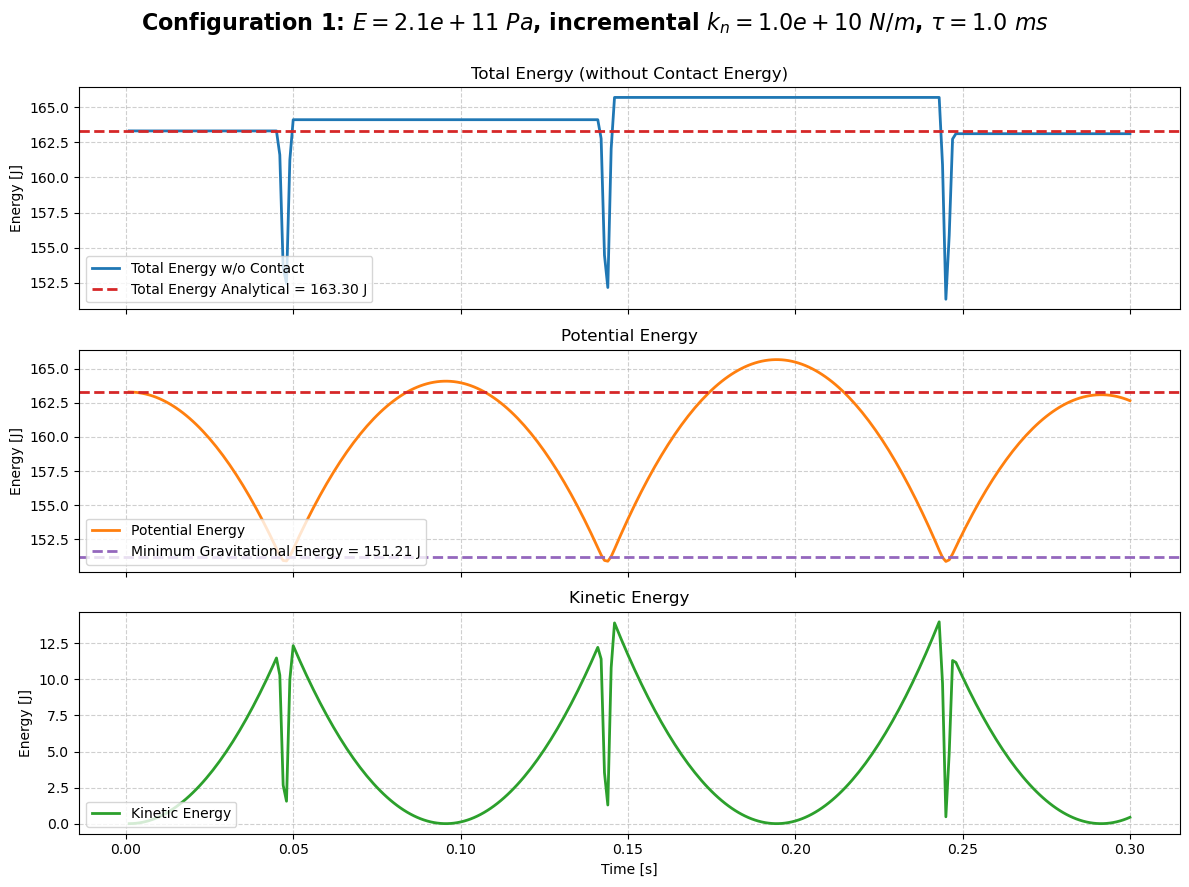

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {'Multidim': {'speed': 30}}, …

In [24]:
config_1 = {'E': 210e9, 'nu': 0.3,'rho': 7850,
            'gap_type': 'incremental', 'kn': 1e10,
            'tau': 1e-3, 'tend': 0.3}

res_config_1 = run_test_case(config_1, animate=False)

plot_energy(config_1, res_config_1, name="1")

animate(res_config_1['u_history'])

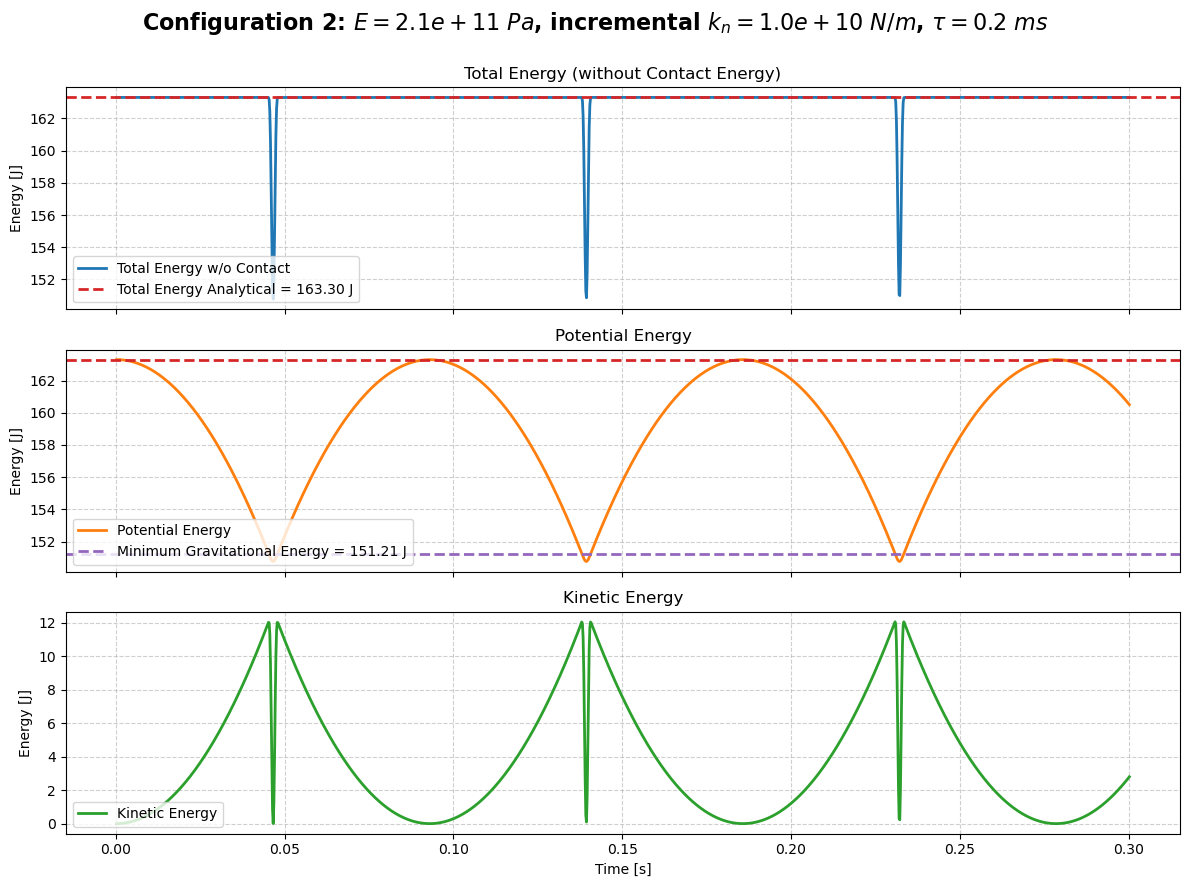

In [25]:
config_2 = {'E': 210e9, 'nu': 0.3, 'rho': 7850,
            'gap_type': 'incremental', 'kn': 1e10,
            'tau': 2e-4, 'tend': 0.3}

res_config_2 = run_test_case(config_2, animate=False)

plot_energy(config_2, res_config_2, name="2")

# animate(res_config_2['u_history'])

In [26]:
config_3 = {'E': 210e9, 'nu': 0.3, 'rho': 7850,
            'material_law': 'linear_elastic', 
            'gap_type': 'absolute', 'kn': 1e7,
            'tau': 2e-4, 'tend': 0.3}

res_config_3 = run_test_case(config_3, animate=False)

plot_energy(config_3, res_config_3, name="3")

#animate(res_config_3['u_history'])

KeyboardInterrupt: 

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

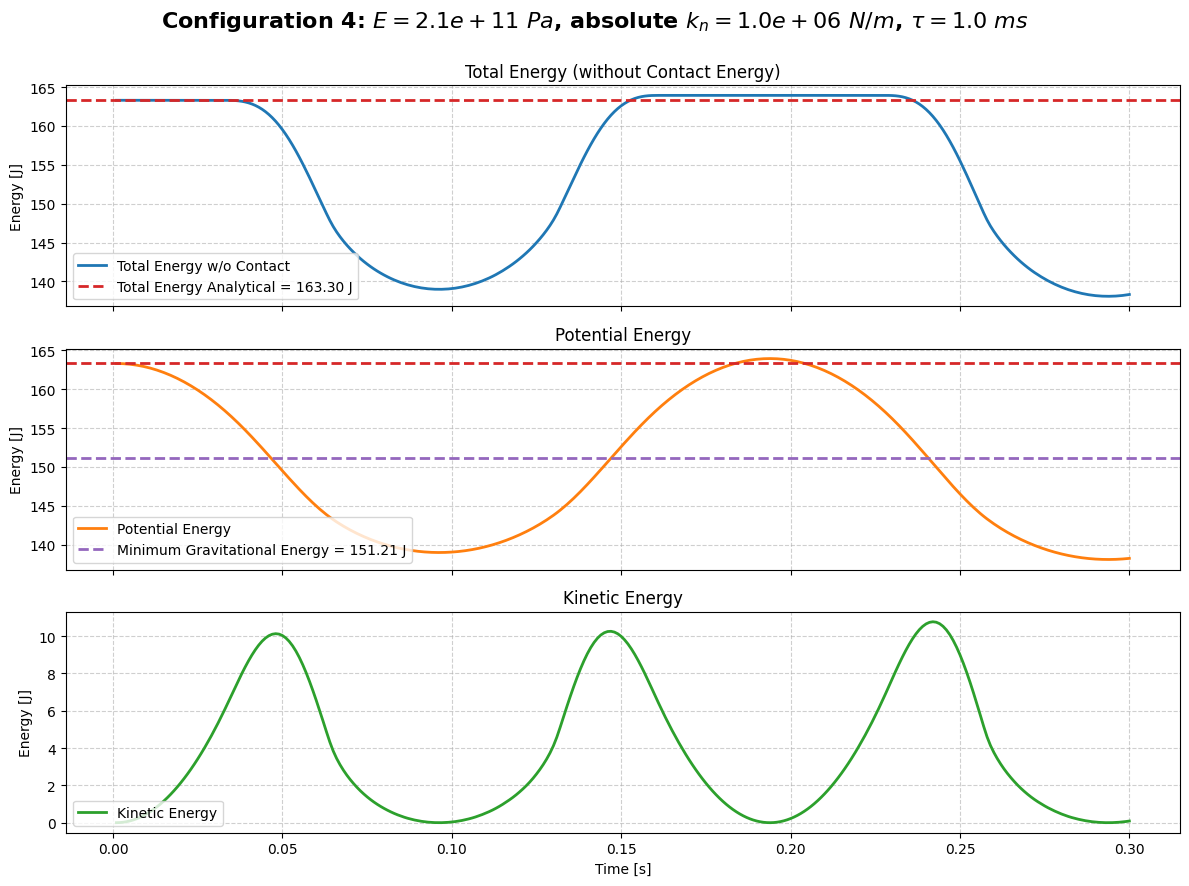

In [ ]:
config_4 = {'E': 210e9, 'nu': 0.3,'rho': 7850,
            'gap_type': 'absolute', 'kn': 1e6,
            'tau': 1e-3, 'tend': 0.3}

res_config_4 = run_test_case(config_4, animate=True)

plot_energy(config_4, res_config_4, name="4")

#animate(res_config_4['u_history'])

In [ ]:
configs_1 = [config_1, config_2, config_3, config_4]
results_1 = [res_config_1, res_config_2, res_config_3, res_config_4]

times_1   = [np.array(res["time"]) for res in results_1]
E_kins_1  = [np.array(res["E_kin"]) for res in results_1]
E_gravs_1 = [np.array(res["E_pot"]) for res in results_1]
E_tots_1  = [np.array(res["E_tot"]) for res in results_1]
E_cons_1  = [np.array(res["E_con"]) for res in results_1]
vy_cms_1  = [np.array(res["vy_cm"]) for res in results_1]

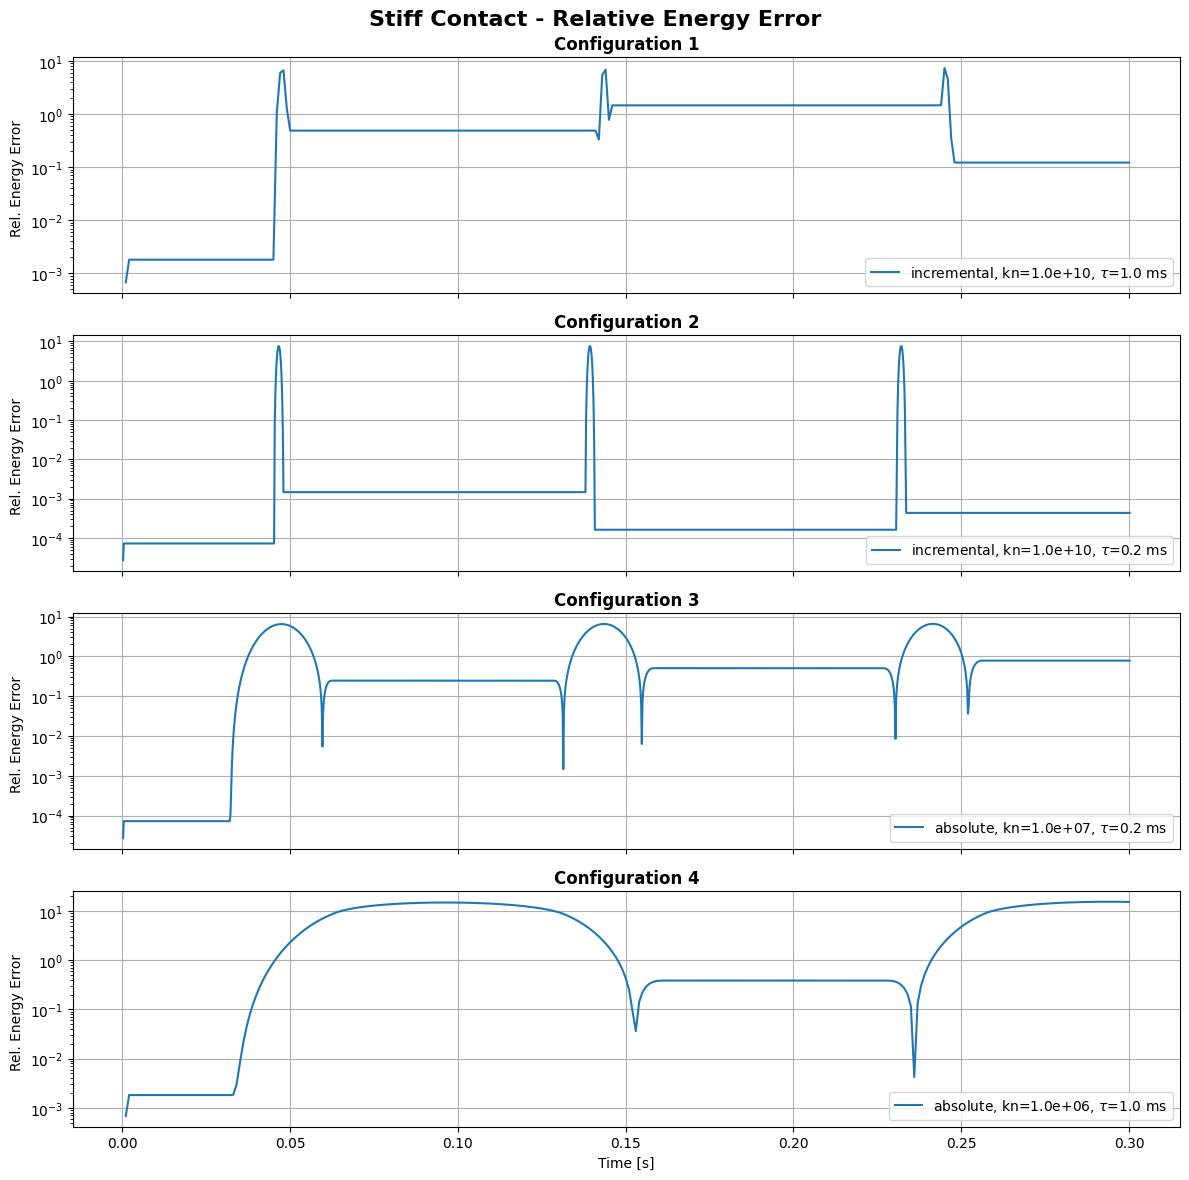

In [ ]:
rho = config_1['rho']
A_ball = Integrate(1, mesh, definedon=mesh.Materials("ball"))
E_tot_th = rho * g * A_ball * thickness * (h0_ball)
E_grav_min_th = rho * g * A_ball * thickness * (h0_ball - h_fall)
rel_errors_1 = [abs(E_tot - E_tot_th) / abs(E_tot_th) for E_tot in E_tots_1]

# Plotting
fig, axs = plt.subplots(len(rel_errors_1), 1, figsize=(12, 3*len(rel_errors_1)), sharex=True)
fig.suptitle('Stiff Contact - Relative Energy Error', fontsize=16, fontweight='bold')
for i, rel_error in enumerate(rel_errors_1):
    axs[i].semilogy(times_1[i], np.array(rel_error)*100, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}, $\\tau$={configs_1[i]["tau"]*1e3:.1f} ms')
    axs[i].set_ylabel('Rel. Energy Error ')
    axs[i].set_title(f'Configuration {i+1}', fontweight='bold')
    axs[i].grid()
    axs[i].legend(loc='lower right')
axs[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.savefig('images/stiff_contact_rel_error.svg', dpi=300, bbox_inches='tight')
plt.show()

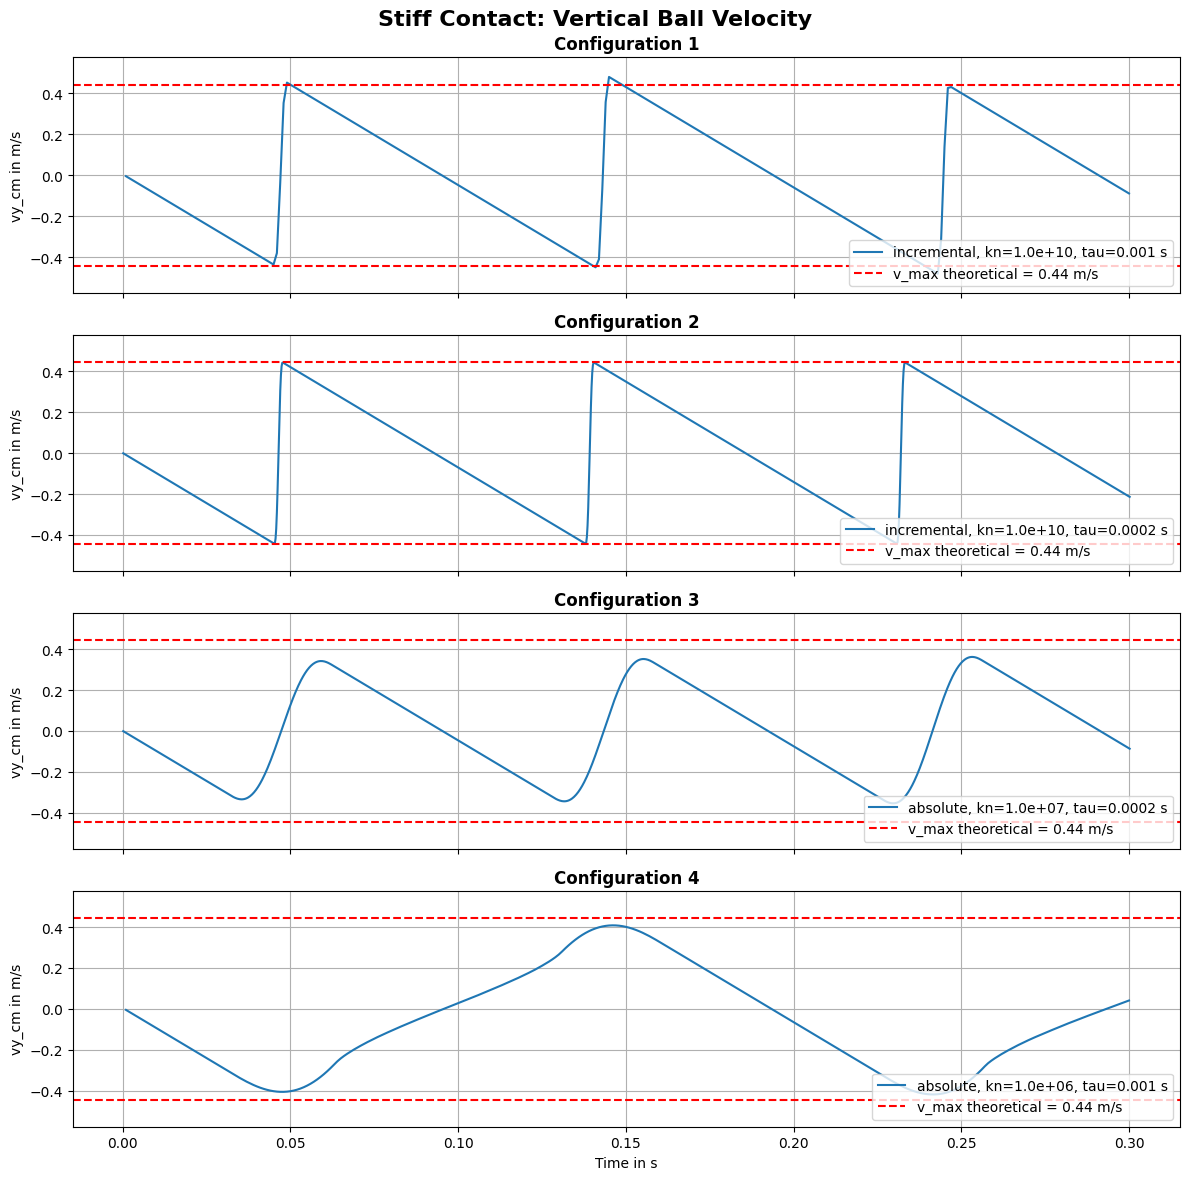

In [ ]:
fig, axs = plt.subplots(len(vy_cms_1), 1, figsize=(12, 3*len(vy_cms_1)), sharex=True)
fig.suptitle('Stiff Contact: Vertical Ball Velocity', fontsize=16, fontweight='bold')
for i, vy_cm in enumerate(vy_cms_1):
    axs[i].plot(times_1[i], vy_cm, label=f'{configs_1[i]["gap_type"]}, kn={configs_1[i]["kn"]:.1e}, tau={configs_1[i]["tau"]} s')
    axs[i].axhline(v_max_th, color='r', linestyle='--', label='v_max theoretical = {:.2f} m/s'.format(v_max_th))
    axs[i].axhline(-v_max_th, color='r', linestyle='--')
    axs[i].set_ylim(-1.3*v_max_th, 1.3*v_max_th)
    axs[i].set_ylabel('vy_cm in m/s')
    axs[i].set_title(f'Configuration {i+1}', fontweight='bold')
    axs[i].grid()
    axs[i].legend(loc='lower right')
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.savefig('images/linear_elastic_v_ball.png', dpi=300)
plt.show()

### Test Case 2: Compliant Ball

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

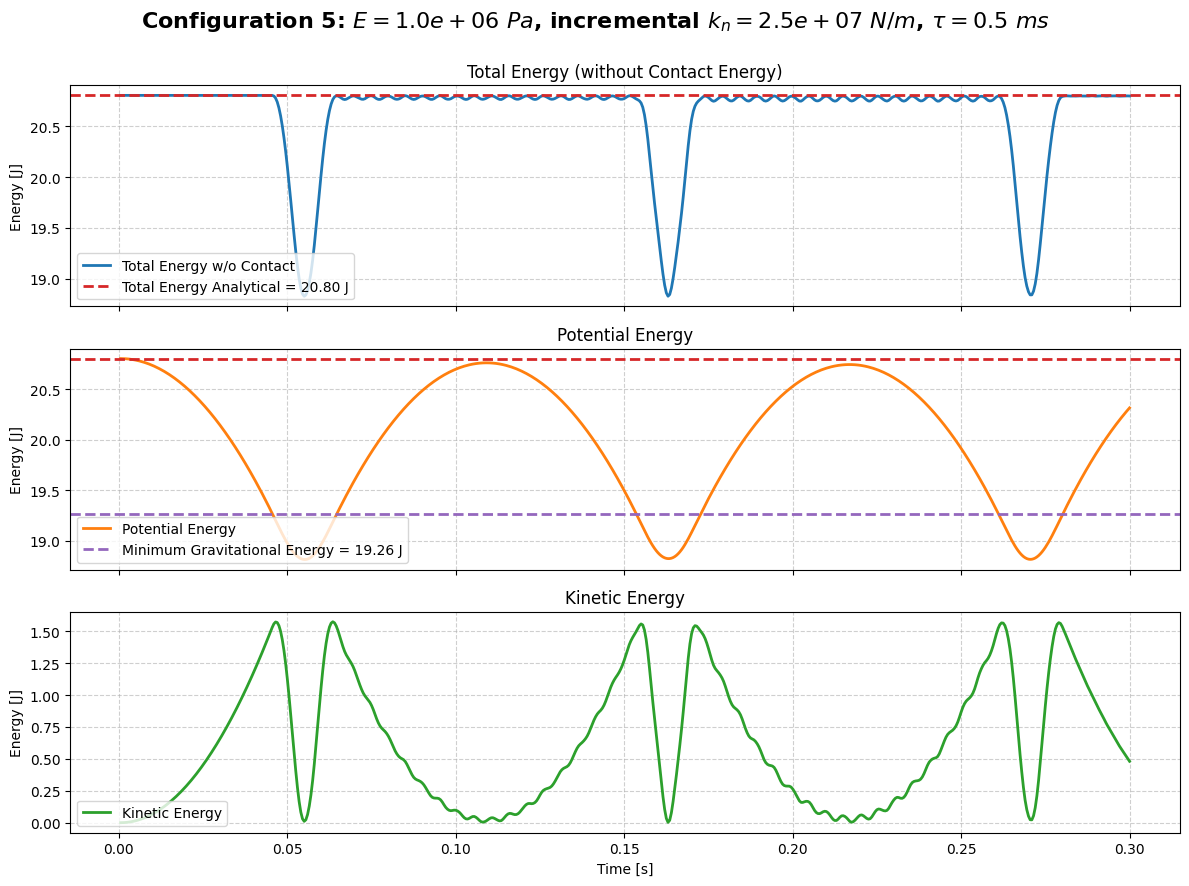

In [ ]:
config_5 = {'E': 1e6, 'nu': 0.45, 'rho': 1000,
            'gap_type': 'incremental', 'kn': 2.5e7,
            'tau': 0.0005, 'tend': 0.3}

res_config_5 = run_test_case(config_5, animate=True)

plot_energy(config_5, res_config_5, name="5")

#animate(res_config_5['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

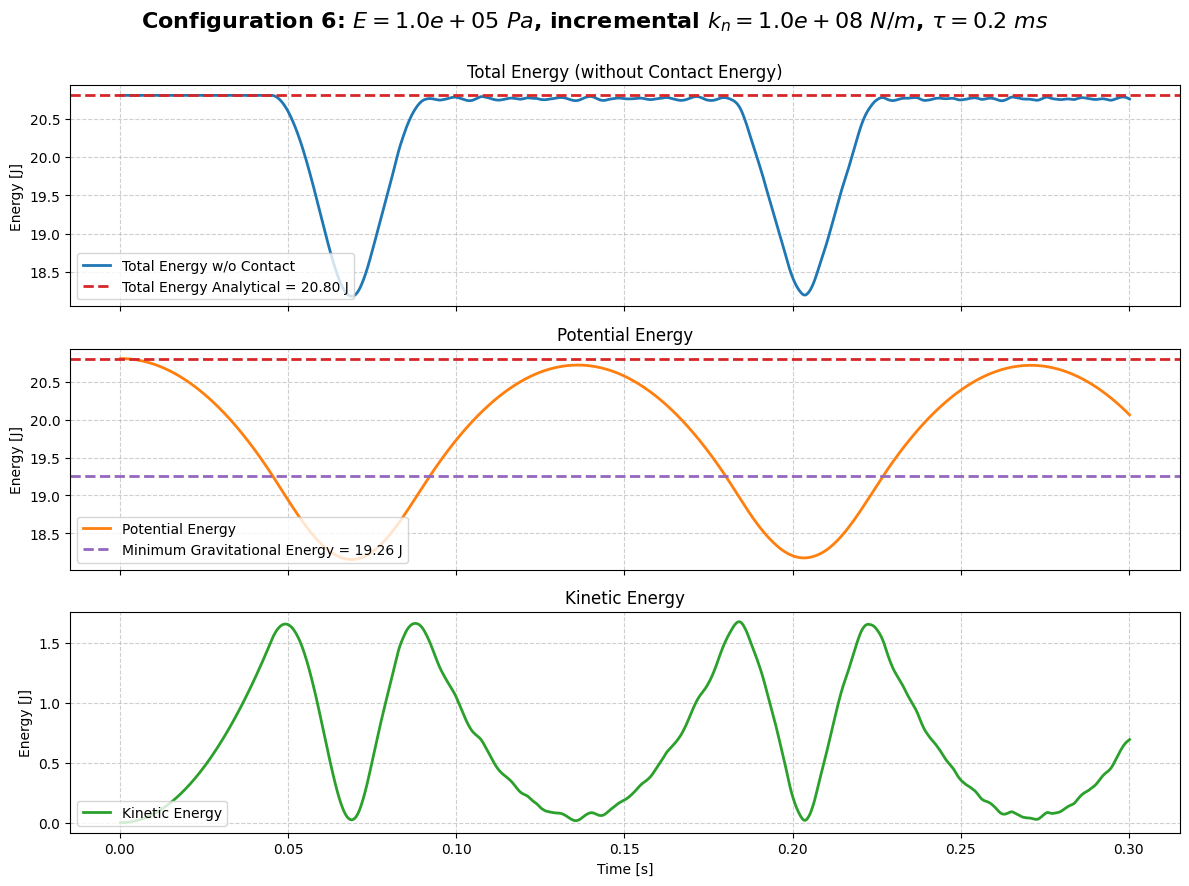

In [ ]:

config_6 = {'E': 1e5, 'nu': 0.45, 'rho': 1000,
            'material_law': 'neo_hookean',
            'gap_type': 'incremental', 'kn': 1e8,
            'tau': 0.0002, 'tend': 0.3}

res_config_6 = run_test_case(config_6, animate=True)

plot_energy(config_6, res_config_6, name="6")

#animate(res_config_6['u_history'])

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

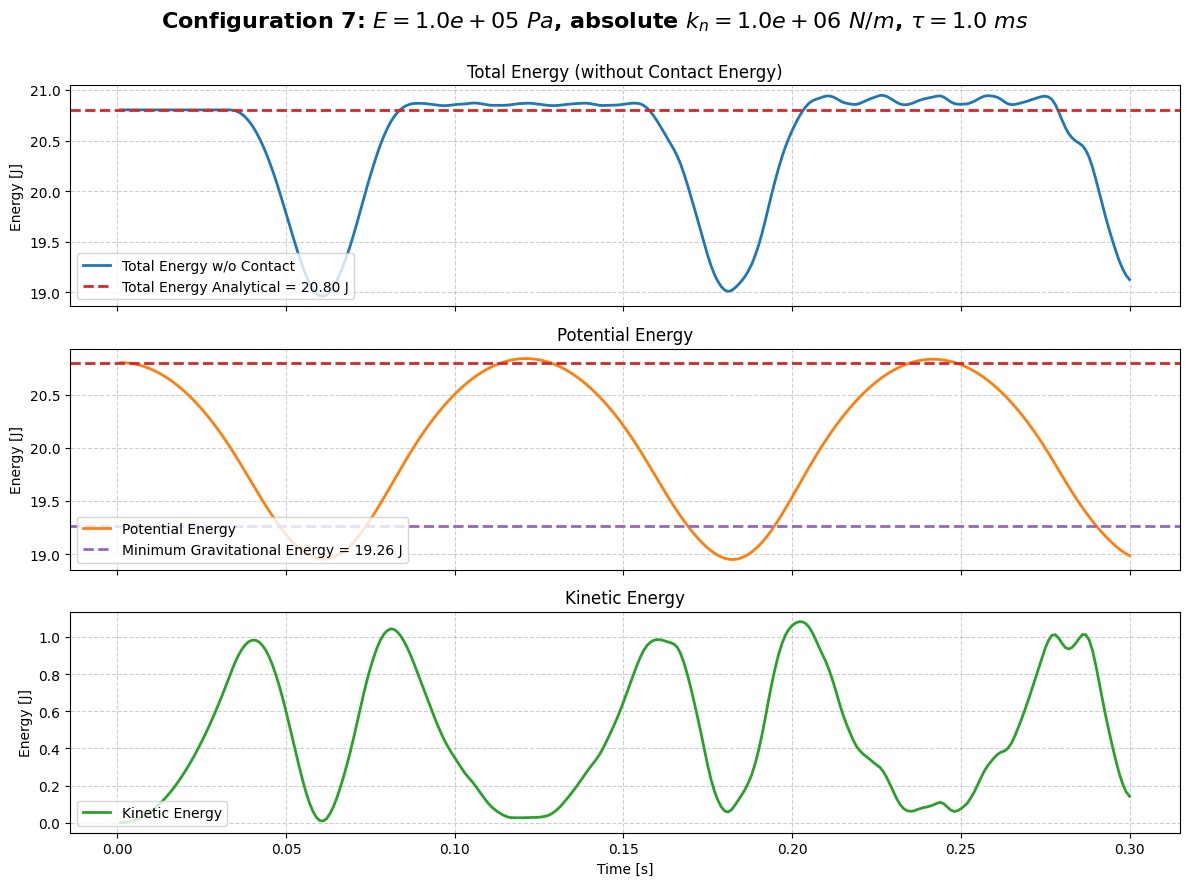

In [ ]:
config_7 = {'E': 1e5, 'nu': 0.45, 'rho': 1000,
            'material_law': 'neo_hookean',
            'gap_type': 'absolute', 'kn': 1e6,
            'tau': 0.001, 'tend': 0.3}

res_config_7 = run_test_case(config_7, animate=True)

plot_energy(config_7, res_config_7, name="7")

#animate(res_config_6['u_history'])

In [ ]:
configs_2 = [config_5, config_6, config_7]
results_2 = [res_config_5, res_config_6, res_config_7]

times_2   = [np.array(res["time"]) for res in results_2]
E_kins_2  = [np.array(res["E_kin"]) for res in results_2]
E_gravs_2 = [np.array(res["E_pot"]) for res in results_2]
E_tots_2  = [np.array(res["E_tot"]) for res in results_2]
E_cons_2  = [np.array(res["E_con"]) for res in results_2]
vy_cms_2  = [np.array(res["vy_cm"]) for res in results_2]

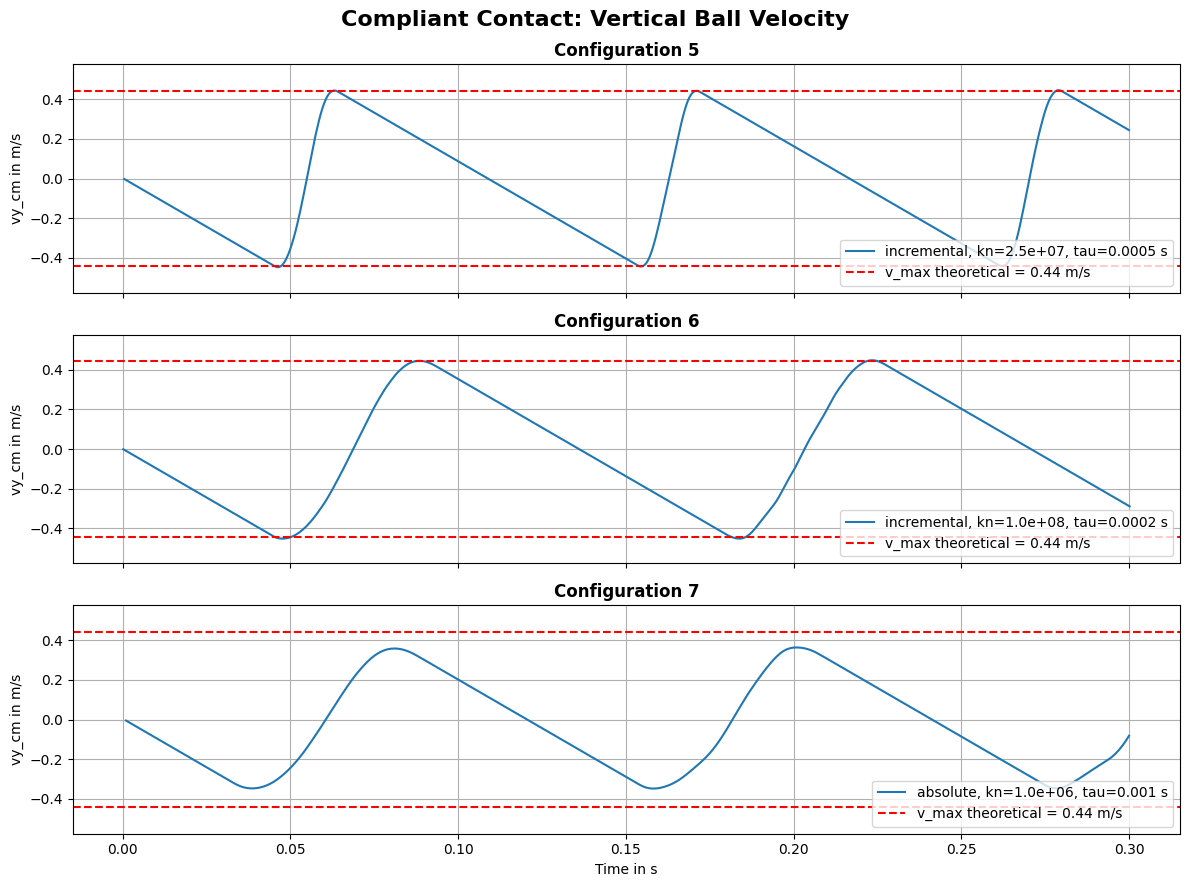

In [ ]:
fig, axs = plt.subplots(len(vy_cms_2), 1, figsize=(12, 3*len(vy_cms_2)), sharex=True)
fig.suptitle('Compliant Contact: Vertical Ball Velocity', fontsize=16, fontweight='bold')
for i, vy_cm in enumerate(vy_cms_2):
    axs[i].plot(times_2[i], vy_cm, label=f'{configs_2[i]["gap_type"]}, kn={configs_2[i]["kn"]:.1e}, tau={configs_2[i]["tau"]} s')
    axs[i].axhline(v_max_th, color='r', linestyle='--', label='v_max theoretical = {:.2f} m/s'.format(v_max_th))
    axs[i].axhline(-v_max_th, color='r', linestyle='--')
    axs[i].set_ylim(-1.3*v_max_th, 1.3*v_max_th)
    axs[i].set_ylabel('vy_cm in m/s')
    axs[i].set_title(f'Configuration {i+5}', fontweight='bold')
    axs[i].grid()
    axs[i].legend(loc='lower right')
axs[-1].set_xlabel('Time in s')
plt.tight_layout()
plt.savefig('images/compliant_contact_v_ball.svg', dpi=300, bbox_inches='tight')
plt.show()

------------------------------------------

### **Conclusion**

- Higher contact stiffness require smaller time steps to achieve energy conservation (see config 1 & 2). Greater time step causes greater increments and therefore greater energy terms are added to the system.

- Energy conservation can be achieved by optimizing the time step size and penalty parameter. Energy conservation is shown in the total system energy before and after impact which remains nearly constant. Contact energy is thus the difference between the total energy before and the error during the impact. Goal would be to calculate the contact energy also using the coefficient function `cf` and the contact stiffness `k_n` explicitly.

- Contact introduces error into the system energy (see Figure: Linear Elastic Material: Vertical Ball Velocity)

- Absolute gap formulation is less capable of handling stiff contact at the contact boundary. Using a high penalty parameter causes the ball to be reflected before it reaches the contact boundary. Using a lower penalty parameter causes the ball to penetrate the wall significantly.

- **Goal:** Find a relationship between penalty parameter, time step size, and material stiffness to achieve energy conservation.